In [2]:
import numpy as np
from scipy.fft import fft, fftfreq, fftshift
import matplotlib.pyplot as plt
from matplotlib import animation
from lmfit.models import LinearModel
import uncertainties as unc
from uncertainties import unumpy as unp

from glob import glob
import h5py
import os

from vysxd_define import *
from vysxd_analysis import *

In [65]:
rootdir = './TeTi-10_2ion-light-drive_iaw-damping-sims/'
subdir = 'tratio-10_light-drive_1'
simdir = os.path.join(rootdir, subdir)
figdir = os.path.join(rootdir, 'figures/')

e1_path = os.path.join(simdir, 'MS/FLD/e1/')
e1, dt, dx_e1, t, x_e1 = get_osiris_quantity_1d(e1_path)

nh_path = os.path.join(simdir, 'MS/DENSITY/heavy_ion/charge/')
nh, dt, dx_nh, t, x_nh = get_osiris_quantity_1d(nh_path)

nl_path = os.path.join(simdir, 'MS/DENSITY/light_ion/charge/')
nl, dt, dx_nl, t, x_nl = get_osiris_quantity_1d(nl_path)

p1x1_h_path = os.path.join(simdir, 'MS/PHA/p1x1/heavy_ion/')
p1x1_h, dt, dx_p1x1, dp1, t_p1x1, x_p1x1, p1 = get_osiris_quantity_2d(p1x1_h_path)

p1x1_h /= p1x1_h.sum(axis=(1,2))[:,None,None]

p1x1_l_path = os.path.join(simdir, 'MS/PHA/p1x1/light_ion/')
p1x1_l, dt, dx_p1x1, dp1, t_p1x1, x_p1x1, p1 = get_osiris_quantity_2d(p1x1_l_path)

p1x1_l /= p1x1_l.sum(axis=(1,2))[:,None,None]

v_the = 0.1
v_h = 0.1 / np.sqrt(1000)
v_l = 0.1 / np.sqrt(100)

k_target = 2.40140140 # tratio-10_1
w_target = 0.02787934
# k_target = 3.80280280 # tratio-10_2
# w_target = 0.04306136
# k_target = 5.20420420 # tratio-10_3
# w_target = 0.05703554
# k_target = 6.60560560 # tratio-10_4
# w_target = 0.06972163
# k_target = 8.00700700 # tratio-10_5
# w_target = 0.08119401
# k_target = 9.40840840 # tratio-10_6
# w_target = 0.09160667
# k_target = 10.80980980 # tratio-10_7
# w_target = 0.10113485
# k_target = 12.21121120 # tratio-10_8
# w_target = 0.10994224
# k_target = 13.61261260 # tratio-10_9
# w_target = 0.11816796

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:6: RuntimeWarning: divide by zero encountered in log10
  


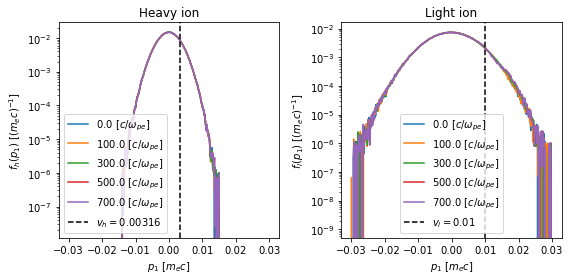

In [71]:
t_chosen = 0.
t_index = np.argmin(np.abs(t_p1x1 - t_chosen))
fig, (ax_h, ax_l) = plt.subplots(1, 2, figsize=(8,4))

# pca = ax.pcolormesh(x_p1x1, p1, np.log10(p1x1_ion[t_index]))
ax.plot(p1, np.log10(p1x1_h[t_index].sum(axis=1)))

chosen_times = [0., 100., 300., 500., 700.]

for t_chosen in chosen_times:
    t_index = np.argmin(np.abs(t_p1x1 - t_chosen))
    ax_h.plot(p1, p1x1_h[t_index].sum(axis=1), label=rf'${t_chosen}~[c/\omega_{{pe}}]$')
    ax_l.plot(p1, p1x1_l[t_index].sum(axis=1), label=rf'${t_chosen}~[c/\omega_{{pe}}]$')

ax_h.axvline(v_h, c='k', ls='--', label=rf'$v_{{h}} = {v_h:.3}$')
ax_l.axvline(v_l, c='k', ls='--', label=rf'$v_{{l}} = {v_l:.3}$')
ax_h.legend()
ax_l.legend()
ax_h.set_yscale('log')
ax_l.set_yscale('log')
ax_h.set_xlabel(r'$p_1~[m_e c]$')
ax_h.set_ylabel(r'$f_{h} (p_1)~[(m_e c)^{-1}]$')
ax_l.set_xlabel(r'$p_1~[m_e c]$')
ax_l.set_ylabel(r'$f_{l} (p_1)~[(m_e c)^{-1}]$')

ax_h.set_title('Heavy ion')
ax_l.set_title('Light ion')

fig.tight_layout()
fname = os.path.join(figdir, subdir + '_p1_hl-t.png')
fig.savefig(fname, dpi=200)

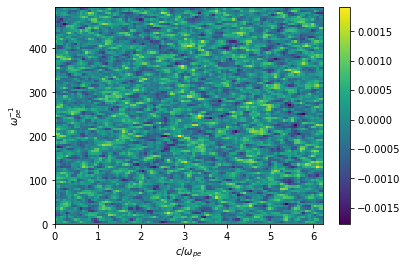

In [6]:
xx_e1, tt_e1 = np.meshgrid(x_e1, t)

plt.pcolormesh(xx_e1, tt_e1, e1)

plt.ylabel(r'$\omega_{pe}^{-1}$')
plt.xlabel(r'$c/\omega_{pe}$')
plt.colorbar()

fname = os.path.join(figdir, subdir + '_e1_x-t.png')
plt.savefig(fname, dpi=200)

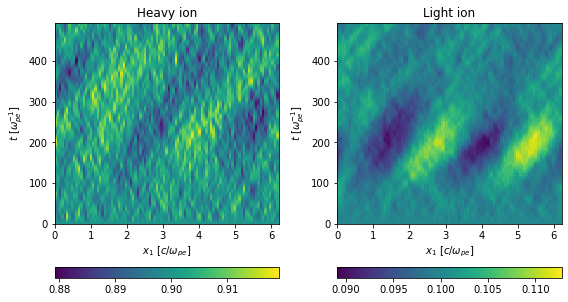

In [63]:
xx_nh, tt_nh = np.meshgrid(x_nh, t)
xx_nl, tt_nl = np.meshgrid(x_nl, t)

fig, (ax_h, ax_l) = plt.subplots(1, 2, figsize=(8,4.5))

cax_h = ax_h.pcolormesh(xx_nh, tt_nh, nh)
ax_h.set_ylabel(r'$t~[\omega_{pe}^{-1}]$')
ax_h.set_xlabel(r'$x_1~[c/\omega_{pe}]$')
fig.colorbar(cax_h, ax=ax_h, orientation='horizontal')
ax_h.set_title('Heavy ion')

cax_l = ax_l.pcolormesh(xx_nl, tt_nl, nl)
ax_l.set_ylabel(r'$t~[\omega_{pe}^{-1}]$')
ax_l.set_xlabel(r'$x_1~[c/\omega_{pe}]$')
fig.colorbar(cax_l, ax=ax_l, orientation='horizontal')
ax_l.set_title('Light ion')

fig.tight_layout()

fname = os.path.join(figdir, subdir + '_nhnl_x-t.png')
plt.savefig(fname, dpi=200)

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:9: RuntimeWarning: divide by zero encountered in log10
  if __name__ == '__main__':


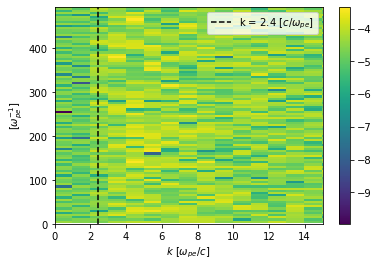

In [9]:
# fft_shift

e1_k_t = fftshift(fft(e1, axis=1), axes=1)
k = 2*np.pi*fftshift(fftfreq(e1.shape[1], d=dx_e1), axes=0)
kk, tt = np.meshgrid(k, t)
e1_mod = np.abs(e1_k_t) ** 2

# plt.pcolormesh(kk, tt, np.log10(e1_mod2))
plt.pcolormesh(kk, tt, np.log10(e1_mod))
plt.axvline(k_target, ls='--', color='k', label=rf'k = {k_target:.3} [$c/\omega_{{pe}}$]')
# plt.xlim((0,k.max()))
plt.colorbar()

plt.xlabel(r'$k~[\omega_{pe}/c]$')
plt.ylabel(r'[$\omega_{pe}^{-1}$]')
plt.legend()
plt.xlim((0., 15.))

fname = os.path.join(figdir, subdir + '_e1_k-t.png')
plt.savefig(fname, dpi=200)

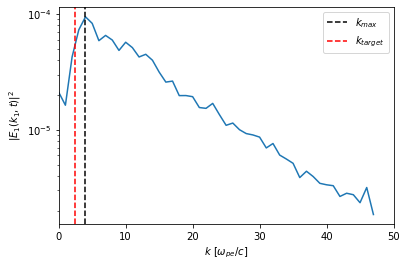

In [42]:
time_averaged_spectrum = e1_mod.mean(axis=0)
k_sorted_ind = np.argsort(time_averaged_spectrum)[::-1]
k_sorted = k[k_sorted_ind]
k_sorted_ind = k_sorted_ind[k_sorted > 0]
# print(k[k_sorted_ind][:10])

time_averaged_spectrum = e1_mod.mean(axis=0)
plt.plot(k, time_averaged_spectrum)
# plt.plot(k[:-1], np.abs(np.diff(time_averaged_spectrum)))
plt.xlim([0, 50])
plt.yscale('log')
plt.axvline(k[k_sorted_ind[0]], ls='--', c='k', label=r'$k_{max}$')
plt.axvline(k_target, ls='--', c='r', label=r'$k_{target}$')
plt.legend()
plt.xlabel(r'$k~[\omega_{pe}/c]$')
plt.ylabel(r'$\left| E_1 (k_1, t) \right|^2$')

fname = os.path.join(figdir, subdir + '_e1_k-lineout.png')
plt.savefig(fname, dpi=200)

dk: 1.0
-0.002678+/-0.003697


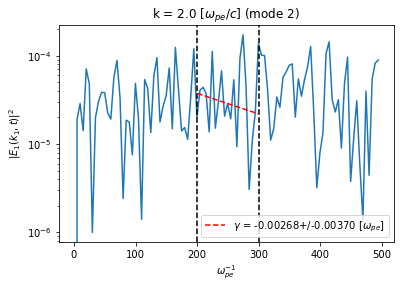

In [43]:
fig, ax = plt.subplots(figsize=(6,4))

dk = k[1] - k[0]
print(f'dk: {dk:.4}')
k_sample_index = np.argmin(np.abs(k - k_target))
mode_num = np.round(k[k_sample_index]/dk).astype('int')
ax.plot(t, e1_mod[:,k_sample_index])
ax.set_yscale('log')
ax.set_xlabel(r'$\omega_{pe}^{-1}$')
ax.set_ylabel(r'$\left| E_1 (k_1, t) \right|^2$')



fit_domain_min_t = 200
fit_domain_max_t = 300

ax.axvline(fit_domain_min_t, ls='--', color='k')
ax.axvline(fit_domain_max_t, ls='--', color='k')

fit_domain_min_index = np.abs(t - fit_domain_min_t).argmin()
fit_domain_max_index = np.abs(t - fit_domain_max_t).argmin()

e1_mod_fit_data = e1_mod[fit_domain_min_index:fit_domain_max_index, k_sample_index]
t_fit_data = t[fit_domain_min_index:fit_domain_max_index]

line = LinearModel()
param_guess = line.guess(np.log10(e1_mod_fit_data), x=t_fit_data)
line_fit = line.fit(np.log10(e1_mod_fit_data), param_guess, x=t_fit_data)

fit_t = np.linspace(fit_domain_min_t, fit_domain_max_t, 100)
m = unc.ufloat(
    line_fit.params['slope'].value, 
    line_fit.params['slope'].stderr
)

b = unc.ufloat(
    line_fit.params['intercept'].value, 
    line_fit.params['intercept'].stderr
)

growth_rate = m * np.log(10) / 2

ax.plot(fit_t, 10**(m.nominal_value * fit_t + b.nominal_value), ls='--', color='r', label=f'$\\gamma$ = {growth_rate:.3} $[\\omega_{{pe}}]$')
ax.legend()
ax.set_title(f'k = {k[k_sample_index]:.3} $[\\omega_{{pe}}/c]$ (mode {mode_num})')

print(f'{growth_rate:.4}')

fname = os.path.join(figdir, subdir + '_e1_k-t_fit.png')
fig.savefig(fname, dpi=200)

## Analyzing and comparing damping rate from heavy and light ion number density

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:15: RuntimeWarning: divide by zero encountered in log10
  from ipykernel import kernelapp as app
/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:26: RuntimeWarning: divide by zero encountered in log10


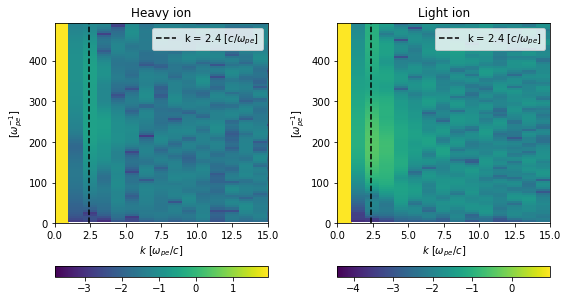

In [59]:
# fft_shift
fig, (ax_h, ax_l) = plt.subplots(1, 2, figsize=(8,4.5))

nh_k_t = fftshift(fft(nh, axis=1), axes=1)
k_nh = 2*np.pi*fftshift(fftfreq(nh.shape[1], d=dx_nh), axes=0)
kk_nh, tt_nh = np.meshgrid(k_nh, t)
nh_mod = np.abs(nh_k_t)

nl_k_t = fftshift(fft(nl, axis=1), axes=1)
k_nl = 2*np.pi*fftshift(fftfreq(nl.shape[1], d=dx_nl), axes=0)
kk_nl, tt_nl = np.meshgrid(k_nl, t)
nl_mod = np.abs(nl_k_t)

# plt.pcolormesh(kk, tt, np.log10(e1_mod2))
cax_h = ax_h.pcolormesh(kk_nh, tt_nh, np.log10(nh_mod))
ax_h.axvline(k_target, ls='--', color='k', label=rf'k = {k_target:.3} [$c/\omega_{{pe}}$]')
# plt.xlim((0,k.max()))
fig.colorbar(cax_h, ax=ax_h, orientation='horizontal')

ax_h.set_xlabel(r'$k~[\omega_{pe}/c]$')
ax_h.set_ylabel(r'[$\omega_{pe}^{-1}$]')
ax_h.legend()
ax_h.set_xlim((0., 15.))
ax_h.set_title('Heavy ion')

cax_l = ax_l.pcolormesh(kk_nl, tt_nl, np.log10(nl_mod))
ax_l.axvline(k_target, ls='--', color='k', label=rf'k = {k_target:.3} [$c/\omega_{{pe}}$]')
# plt.xlim((0,k.max()))
fig.colorbar(cax_l, ax=ax_l, orientation='horizontal')

ax_l.set_xlabel(r'$k~[\omega_{pe}/c]$')
ax_l.set_ylabel(r'[$\omega_{pe}^{-1}$]')
ax_l.legend()
ax_l.set_xlim((0., 15.))
ax_l.set_title('Light ion')

fig.tight_layout()

fname = os.path.join(figdir, subdir + '_nhnl_k-t.png')
plt.savefig(fname, dpi=200)

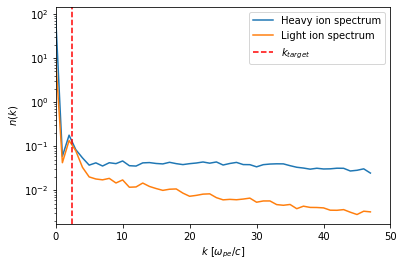

In [57]:
fig, ax = plt.subplots()

nh_time_averaged_spectrum = nh_mod.mean(axis=0)
nl_time_averaged_spectrum = nl_mod.mean(axis=0)

nh_k_sorted_ind = np.argsort(nh_time_averaged_spectrum)[::-1]
nh_k_sorted = k_nh[nh_k_sorted_ind]
nh_k_sorted_ind = nh_k_sorted_ind[nh_k_sorted > 0]

nl_k_sorted_ind = np.argsort(nl_time_averaged_spectrum)[::-1]
nl_k_sorted = k_nl[nl_k_sorted_ind]
nl_k_sorted_ind = nl_k_sorted_ind[nl_k_sorted > 0]

ax.plot(k_nh, nh_time_averaged_spectrum, label='Heavy ion spectrum')
ax.plot(k_nl, nl_time_averaged_spectrum, label='Light ion spectrum')

ax.set_xlim([0, 50])
ax.set_yscale('log')
# plt.axvline(k[k_sorted_ind[0]], ls='--', c='k', label=r'$k_{max}$')
plt.axvline(k_target, ls='--', c='r', label=r'$k_{target}$')
plt.legend()
plt.xlabel(r'$k~[\omega_{pe}/c]$')
plt.ylabel(r'$n(k)$')

fname = os.path.join(figdir, subdir + '_nhnl_k-lineout.png')
plt.savefig(fname, dpi=200)

## Analyzing damping rate from `nl` or light ion number density

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:77: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.


heavy ion γ: -0.001182+/-0.000237
light ion γ: -0.01539+/-0.00030


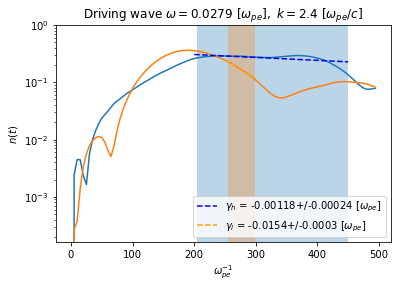

In [58]:
fig, ax = plt.subplots(figsize=(6,4))

dk_nh = k_nh[1] - k_nh[0]
dk_nl = k_nl[1] - k_nl[0]
k_nh_sample_index = np.argmin(np.abs(k_nh - k_target))
k_nl_sample_index = np.argmin(np.abs(k_nl - k_target))
nh_mode_num = np.round(k_nh[k_nh_sample_index]/dk_nh).astype('int')
nl_mode_num = np.round(k_nl[k_nl_sample_index]/dk_nl).astype('int')

ax.plot(t, nh_mod[:,k_nh_sample_index])
ax.plot(t, nl_mod[:,k_nl_sample_index])
ax.set_yscale('log')
ax.set_xlabel(r'$\omega_{pe}^{-1}$')
ax.set_ylabel(r'$n (t)$')

nh_fit_domain_min_t = 200
nh_fit_domain_max_t = 450
nl_fit_domain_min_t = 250
nl_fit_domain_max_t = 300

nh_fit_domain_min_index = np.abs(t - nh_fit_domain_min_t).argmin()
nh_fit_domain_max_index = np.abs(t - nh_fit_domain_max_t).argmin()
nl_fit_domain_min_index = np.abs(t - nl_fit_domain_min_t).argmin()
nl_fit_domain_max_index = np.abs(t - nl_fit_domain_max_t).argmin()

ax.fill_between(t, 0, 10, where=(t>=nh_fit_domain_min_t)&(t<=nh_fit_domain_max_t), alpha=0.3, lw=3)
ax.fill_between(t, 0, 10, where=(t>=nl_fit_domain_min_t)&(t<=nl_fit_domain_max_t), alpha=0.3, lw=3)

nh_mod_fit_data = nh_mod[nh_fit_domain_min_index:nh_fit_domain_max_index, k_nh_sample_index]
nl_mod_fit_data = nl_mod[nl_fit_domain_min_index:nl_fit_domain_max_index, k_nl_sample_index]

nh_t_fit_data = t[nh_fit_domain_min_index:nh_fit_domain_max_index]
nl_t_fit_data = t[nl_fit_domain_min_index:nl_fit_domain_max_index]

nh_line = LinearModel()
nl_line = LinearModel()

nh_param_guess = nh_line.guess(np.log10(nh_mod_fit_data), x=nh_t_fit_data)
nh_line_fit = nh_line.fit(np.log10(nh_mod_fit_data), nh_param_guess, x=nh_t_fit_data)

nl_param_guess = nl_line.guess(np.log10(nl_mod_fit_data), x=nl_t_fit_data)
nl_line_fit = nl_line.fit(np.log10(nl_mod_fit_data), nl_param_guess, x=nl_t_fit_data)

nh_fit_t = np.linspace(nh_fit_domain_min_t, nh_fit_domain_max_t, 100)
nl_fit_t = np.linspace(nl_fit_domain_min_t, nl_fit_domain_max_t, 100)

m_nh = unc.ufloat(
    nh_line_fit.params['slope'].value, 
    nh_line_fit.params['slope'].stderr
)
m_nl = unc.ufloat(
    nl_line_fit.params['slope'].value, 
    nl_line_fit.params['slope'].stderr
)

b_nh = unc.ufloat(
    nh_line_fit.params['intercept'].value, 
    nh_line_fit.params['intercept'].stderr
)


b_nl = unc.ufloat(
    nl_line_fit.params['intercept'].value, 
    nl_line_fit.params['intercept'].stderr
)

nh_growth_rate = m_nh * np.log(10)
nl_growth_rate = m_nl * np.log(10)

ax.plot(nh_fit_t, 10**(m_nh.nominal_value * nh_fit_t + b_nh.nominal_value), ls='--', color='blue', label=f'$\\gamma_h$ = {nh_growth_rate:.3} $[\\omega_{{pe}}]$')
ax.plot(nl_fit_t, 10**(m_nl.nominal_value * nl_fit_t + b_nl.nominal_value), ls='--', color='orange', label=f'$\\gamma_l$ = {nl_growth_rate:.3} $[\\omega_{{pe}}]$')
ax.set_ylim([0.,1.])
ax.legend()
ax.set_title(rf'Driving wave $\omega = {w_target:.3}~[\omega_{{pe}}],~k = {k_target:.3}~[\omega_{{pe}}/c]$')

print(f'heavy ion γ: {nh_growth_rate:.4}')
print(f'light ion γ: {nl_growth_rate:.4}')

fname = os.path.join(figdir, subdir + '_nhnl-comparison_k-t_fit.png')
fig.savefig(fname, dpi=200)